#Trabajo Práctico 2 - Críticas Cinematográficas

#Grupo 2 - G2 - Integrantes:

- Calderan, Facundo Andres
- Merlinsky Camins, Mariano Gabriel
- Castellano Bogdan, Benjamin
- Pons Echeverria, Tomas

# Random Forest

In [1]:
import pandas as pd

# Descargamos los archivos de train y test
!gdown 1MV2mivzC_7gLCqRndSnWizXRGhJBgQ6L
!gdown 1GpCc2ggdH9X4nrfbO80ubK4GF5NGtrzk

# Descargamos los embeddings previamente calculados
!gdown 11-MhYTUcZe2DuU-AyrUM2sn3vd9eoxEE
!gdown 12vha1d30bTCPsl5_oTwHH6qqfBWgSrUO

# Descargamos intelex para acelerar a ScikitLearn
!pip install scikit-learn-intelex -q --progress-bar off
# Descargamos langid
!pip install langid

Downloading...
From: https://drive.google.com/uc?id=1MV2mivzC_7gLCqRndSnWizXRGhJBgQ6L
To: /content/test.csv
100% 11.1M/11.1M [00:00<00:00, 25.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GpCc2ggdH9X4nrfbO80ubK4GF5NGtrzk
To: /content/train.csv
100% 72.2M/72.2M [00:01<00:00, 55.8MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=11-MhYTUcZe2DuU-AyrUM2sn3vd9eoxEE
From (redirected): https://drive.google.com/uc?id=11-MhYTUcZe2DuU-AyrUM2sn3vd9eoxEE&confirm=t&uuid=5ada6e89-6796-4723-b605-dd0c06283785
To: /content/train_emb.npy
100% 148M/148M [00:02<00:00, 49.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=12vha1d30bTCPsl5_oTwHH6qqfBWgSrUO
To: /content/test_emb.npy
100% 26.4M/26.4M [00:00<00:00, 160MB/s] 
  Using cached langid-1.1.6-py3-none-any.whl


In [2]:
# Cargamos los archivos en dataframes
data_train = pd.read_csv('train.csv')
data_test = pd.read_csv('test.csv')

print(data_train.info())
data_train

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           50000 non-null  int64 
 1   review_es    50000 non-null  object
 2   sentimiento  50000 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB
None


,ID,review_es,sentimiento
0,0,Uno de los otros críticos ha mencionado que de...,positivo
1,1,Una pequeña pequeña producción.La técnica de f...,positivo
2,2,Pensé que esta era una manera maravillosa de p...,positivo
3,3,"Básicamente, hay una familia donde un niño peq...",negativo
4,4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
...,...,...,...
49995,49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,49998,Voy a tener que estar en desacuerdo con el com...,negativo


Sacamos criíticas que no estén en español

In [3]:
import langid

def detectar_idioma(texto):
    lang, prob = langid.classify(texto)
    return lang

data_train['idioma'] = data_train['review_es'].apply(detectar_idioma)

data_train = data_train[data_train['idioma'] == 'es']
data_train = data_train.drop('idioma', axis=1)

In [4]:
X = data_train['review_es']
y = data_train['sentimiento']
x_test = data_test['review_es']

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer
from sklearnex import patch_sklearn
import torch
# Calculamos embeddings, comentado por que ya lo hicimos y subimos a drive

# Utilizamos sentence embedding para capturar la semántica de las oraciones
model = SentenceTransformer("hiiamsid/sentence_similarity_spanish_es", device='cuda', model_kwargs={"dtype": torch.bfloat16})

X = X.reset_index(drop=True)

X_train_emb = model.encode(X,batch_size=32 ,show_progress_bar=True)
X_test_emb = model.encode(x_test,batch_size=32, show_progress_bar=True)

scaler = StandardScaler()
X_train_emb = scaler.fit_transform(X_train_emb)
X_test_emb = scaler.transform(X_test_emb)



In [ ]:
import numpy as np
np.save("train_emb.npy", X_train_emb)
np.save("test_emb.npy", X_test_emb)

In [6]:
from sklearn.model_selection import train_test_split

X_train_a = np.load("train_emb.npy")
X_test_a = np.load("test_emb.npy")

print(X_train_a)
print(X_test_a.shape)

X_train, X_val, y_train, y_val = train_test_split(X_train_a, y,
                                                            test_size = 0.2,
                                                            random_state = 42,
                                                            stratify = y
)

[[-0.9909666   0.73021156 -1.165175   ... -0.34301904  0.35789615
  -0.12629664]
 [-0.06768981  1.1367652   0.53578186 ... -1.790469   -0.47189096
  -1.1285605 ]
 [-0.95531887  0.5675901  -0.08388209 ...  0.54742795  1.0238004
  -1.2370145 ]
 ...
 [ 1.0053076   0.39203286 -1.4812453  ...  0.75583047  1.2644386
  -0.56759197]
 [ 1.0979917   1.0776302   0.17396466 ... -0.32028422  1.0378029
  -0.5825511 ]
 [ 0.06242449 -1.5243132   0.09910592 ...  0.630789    0.34544936
   1.0031203 ]]
(8599, 768)


In [ ]:
print(X_train_a)

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
def testear_clasificacion(y_train, y_test, y_train_pred, y_test_pred):
  # Métricas
  metrics = {
      "accuracy": [
          accuracy_score(y_train, y_train_pred),
          accuracy_score(y_test, y_test_pred)
      ],
      "precision": [
          precision_score(y_train, y_train_pred, pos_label='positivo'),
          precision_score(y_test, y_test_pred, pos_label='positivo')
      ],
      "recall": [
          recall_score(y_train, y_train_pred, pos_label='positivo'),
          recall_score(y_test, y_test_pred, pos_label='positivo')
      ],
      "f1_score": [
          f1_score(y_train, y_train_pred, pos_label='positivo'),
          f1_score(y_test, y_test_pred, pos_label='positivo')
      ]
  }

  # Crear tabla
  results = pd.DataFrame(metrics, index=["Train", "Test"])

  # Graficar tabla
  fig, ax = plt.subplots(figsize=(6, 2))
  ax.axis('off')
  ax.axis('tight')
  ax.table(cellText=results.round(3).values,
          colLabels=results.columns,
          rowLabels=results.index,
          loc='center')
  plt.title("Comparativa de métricas: Train vs Test", pad=10)
  plt.show()


  # Graficar Matriz de confusión
  cm = confusion_matrix(y_test, y_test_pred)
  ConfusionMatrixDisplay(cm).plot(cmap='Blues')
  plt.title("Matriz de confusión")
  plt.show()

Iniciando búsqueda rápida...
Fitting 4 folds for each of 10 candidates, totalling 40 fits
Mejores parámetros: {'n_estimators': 120, 'min_samples_split': 5, 'max_samples': 0.7, 'max_features': 'sqrt', 'max_depth': 15}


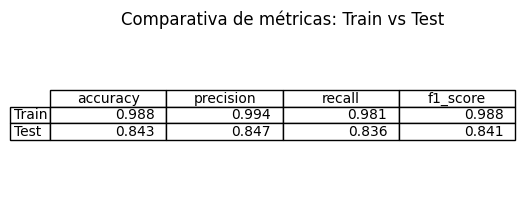

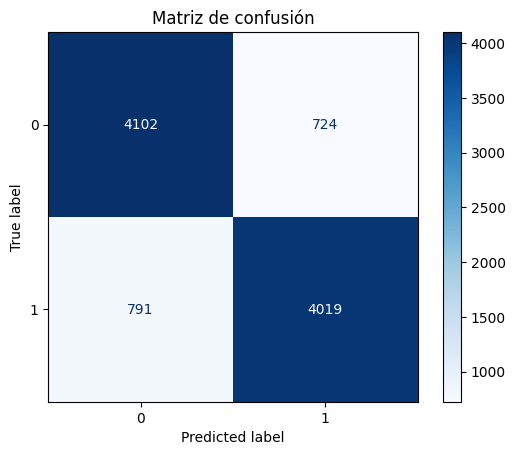

Buscando el mejor umbral...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import joblib
from google.colab import files

param_dist = {
    'n_estimators': [100, 120],
    'max_depth': [15, 20, 25],
    'max_samples': [0.5, 0.7],
    'min_samples_split': [5, 10],
    'max_features': ['sqrt']
}

rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
    bootstrap=True
)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=4,
    scoring="f1_macro",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Iniciando búsqueda rápida...")
random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_
print(f"Mejores parámetros: {random_search.best_params_}")

y_val_pred = best_rf.predict(X_val)

testear_clasificacion(y_train, y_val, best_rf.predict(X_train), y_val_pred)

data_test['sentimiento'] = best_rf.predict(X_test_a)

y_val_probs = best_rf.predict_proba(X_val)[:, 1]

best_threshold = 0.5
best_f1 = 0.0

print("Buscando el mejor umbral...")
for tr in np.arange(0.3, 0.7, 0.01):
    y_pred_temp = np.where(y_val_probs >= tr, 'positivo', 'negativo')

    f1_temp = f1_score(y_val, y_pred_temp, pos_label='positivo')

    if f1_temp > best_f1:
        best_f1 = f1_temp
        best_threshold = tr

y_test_probs = best_rf.predict_proba(X_test_a)[:, 1]

data_test['sentimiento'] = np.where(y_test_probs >= best_threshold, 'positivo', 'negativo')

data_test = data_test.drop('review_es', axis=True)

data_test.to_csv('submission.csv', index=False)

joblib.dump(random_search, 'random_forest_model.joblib')

files.download('random_forest_model.joblib')